# Hyperparameter Analysis

In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any, Union, Tuple
from tiny_hanabi.game.payoff_matrices import OPTIMAL_RETURNS

sns.set_theme(style="whitegrid")
# --- CONFIGURATION ---
INPUT_RESULTS_DIR = "HyperSearchResults"
BEST_PARAMS_DIR = "Results"
GAMES = ["A", "B", "C", "D", "E", "F", "G"]

In [2]:
def load_hyperparameter_results(agent_name):
    """
    Loads all result files for a specific agent.
    
    Returns:
        tuple: (sorted_results, best_count_score)
        
        - sorted_results: List of tuples [(df, params, solved_count), ...] 
                          sorted by solved_count descending.
        - best_count_score: Integer indicating how many parameter sets achieved 
                            the maximum number of solved games found.
    """
    folder_name = agent_name.replace(" ", "_")
    search_dir = os.path.join(INPUT_RESULTS_DIR, folder_name)
    
    if not os.path.exists(search_dir):
        print(f"Directory not found: {search_dir}")
        return [], 0

    # Get all result CSVs
    csv_files = glob.glob(os.path.join(search_dir, "*_results.csv"))
    
    loaded_results = []
    
    print(f"Loading {len(csv_files)} files for {agent_name}...")

    for csv_path in csv_files:
        # 1. Parse ID and Paths
        file_name = os.path.basename(csv_path)
        file_id = int(file_name.split("_")[0])
        json_path = os.path.join(search_dir, f"{file_id}_params.json")
        
        # 2. Load Data
        df = pd.read_csv(csv_path)
        with open(json_path, 'r') as f:
            params = json.load(f)
        
        # Inject ID into params for reference
        loaded_results.append((df, params, file_id))

    return loaded_results

In [3]:
def plot_all_reward(all_results : List[Tuple[pd.DataFrame, dict, int]]):
    fig, axes = plt.subplots(1, len(GAMES), figsize=(4 * len(GAMES), 4), sharey=False)
    # Sort the list according to rewards. from Low To High
    for ax, game in zip(axes, GAMES):
        values = []

        for df, params, file_id in all_results:
            col = f"reward_{game}"
            if col in df.columns and len(df[col]) > 0:
                values.append(df[col].iloc[-1])

        if len(values) == 0:
            ax.set_title(f"Game {game} (no data)")
            continue

        values = np.sort(values)

        ax.scatter(range(len(values)), values, alpha=0.7)
        ax.set_title(f"Game {game}")
        ax.set_xlabel("Hyperparameter setting (sorted)")
        ax.set_ylabel("Final Reward")

    plt.tight_layout()
    plt.show()
    # Scatter Plot off final rewards per game
    return

def plot_all_loss(all_results: List[Tuple[pd.DataFrame, dict, int]]):
    fig, axes = plt.subplots(1, len(GAMES), figsize=(4 * len(GAMES), 4), sharey=False)

    for ax, game in zip(axes, GAMES):
        values = []

        for df, params, file_id in all_results:
            col = f"loss_{game}"
            if col in df.columns and len(df[col]) > 0:
                values.append(df[col].iloc[-1])

        if len(values) == 0:
            ax.set_title(f"Game {game} (no data)")
            continue

        values = np.sort(values)

        ax.scatter(range(len(values)), values, alpha=0.7)
        ax.set_title(f"Game {game}")
        ax.set_xlabel("Hyperparameter setting (sorted)")
        ax.set_ylabel("Final Loss")

    plt.tight_layout()
    plt.show()


In [4]:
def visualize_agent_performance(results_list, agent_name, top_n=5):
    """
    Visualizes the training curves for the top N performing parameter sets.
    
    Args:
        results_list: The list of tuples returned by the loader. 
                      Can accept (list, score) tuple and unpack automatically.
        agent_name: Name of the agent for titling.
        top_n: Number of top results to display.
    """
    # --- AUTO-UNPACK TUPLE FIX ---
    if isinstance(results_list, tuple):
        results_list = results_list[0]
        
    if not results_list:
        print(f"No results to visualize for {agent_name}.")
        return

    # Take Top N (List is already sorted by solved_count from the loader)
    top_results = results_list[:top_n]

    print(f"--- Visualizing Top {len(top_results)} Configurations for {agent_name} ---")

    for rank, (df, params, solved_count) in enumerate(top_results):
        # Extract ID safely
        param_id = params.get('id', 'Unknown')
        
        # --- PRINT METADATA ---
        print("\n" + "="*100)
        print(f"🔹 RANK {rank+1} | ID: {param_id} | SOLVED: {solved_count}/6")
        print("-" * 100)
        # Filter out large objects for clean printing
        clean_params = {k: v for k, v in params.items() if k not in ['id', 'solved_count']}
        print(json.dumps(clean_params, indent=4))
        print("="*100)

        # --- SETUP PLOT (1 Row, 6 Columns) ---
        # constrained_layout helps with spacing better than tight_layout sometimes
        fig, axes = plt.subplots(nrows=1, ncols=len(GAMES), figsize=(24, 4), constrained_layout=True)
        
        # Ensure axes is iterable even if only 1 game defined
        if len(GAMES) == 1: 
            axes = [axes]

        for col_idx, game in enumerate(GAMES):
            ax = axes[col_idx]
            col_name = f"reward_{game}"
            
            # Get Optimal Return
            opt_val = 1.0

            if col_name in df.columns:
                data = df[col_name]
                # Create explicit x-axis (Episode number)
                episodes = list(range(1, len(data) + 1))
                
                # 1. Plot Optimal Line
                if opt_val is not None:
                    ax.axhline(y=opt_val, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Opt: {opt_val}')
                
                # 2. Plot Training Curve (Raw Data)
                # marker='o' ensures we see points even if there is only 1 episode
                ax.plot(episodes, data, color='tab:blue', linewidth=2, marker='.', markersize=8, alpha=0.9, label='Agent')
                
                # 3. Dynamic Scaling
                max_val = data.max()
                
                # Determine Upper Limit
                if opt_val:
                    upper = max(max_val, opt_val)
                    if upper == 0: upper = 1.0 # Prevent flat line at 0 scaling weirdly
                    ax.set_ylim(bottom=0, top=upper * 1.1)
                else:
                    if max_val == 0: max_val = 1.0
                    ax.set_ylim(bottom=0, top=max_val * 1.1)

                # 4. Labels & Legend
                ax.set_title(f"Game {game}", fontsize=14, fontweight='bold')
                ax.set_xlabel("Episode")
                if col_idx == 0:
                    ax.set_ylabel("Reward")
                    if opt_val is not None:
                        ax.legend(loc='lower right', fontsize='small')
            else:
                # Handle missing data
                ax.text(0.5, 0.5, "No Data", ha='center', va='center', color='gray')
                ax.set_title(f"Game {game} (N/A)")
                ax.axis('off')

        fig.suptitle(f"Rank {rank+1} (ID {param_id}) Training Trace", fontsize=16)
        plt.show()

In [5]:
def save_best_params(agent_name, params_dict):
    folder_name = agent_name.replace(" ", "_")
    output_dir = os.path.join(BEST_PARAMS_DIR, folder_name)
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, "best_params.json")
    with open(file_path, 'w') as f:
        json.dump(params_dict, f, indent=4)
    print(f"✅ Params saved to: {file_path}")

### Indepdenent Q Learning - Model Free

In [6]:
AGENT_NAME = "IQ_Learning"
results = load_hyperparameter_results(AGENT_NAME)

Loading 216 files for IQ_Learning...


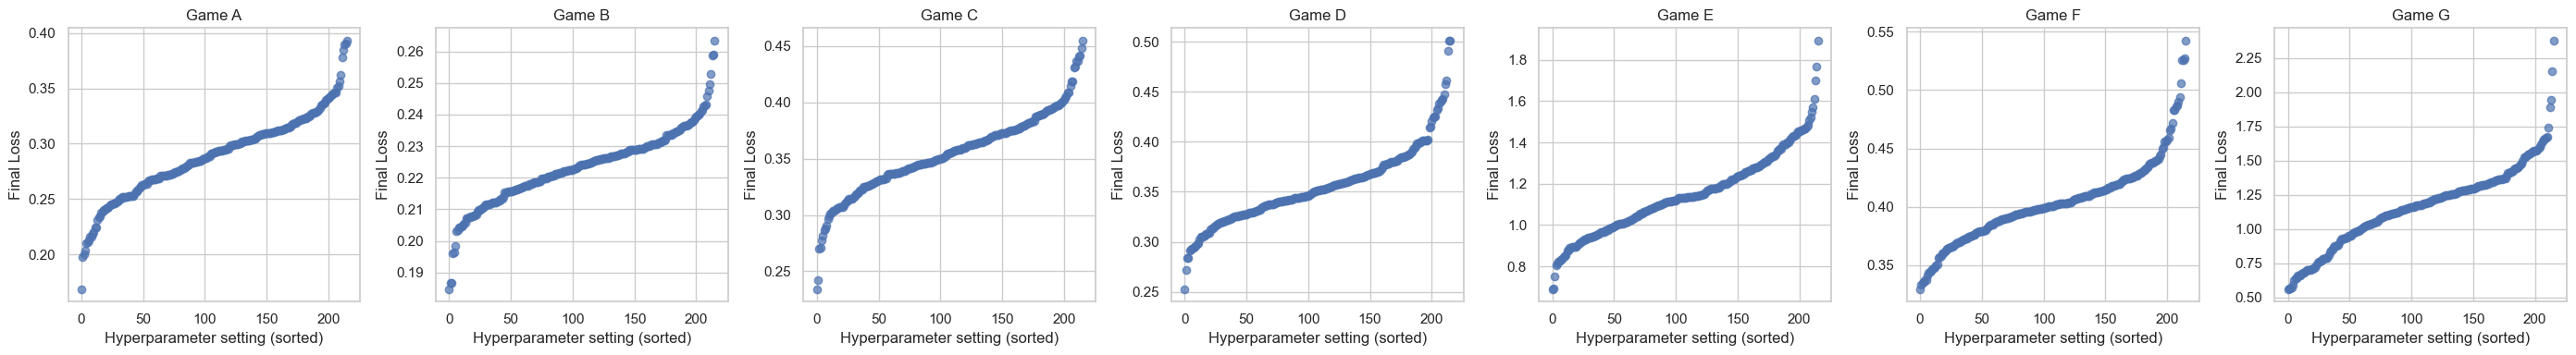

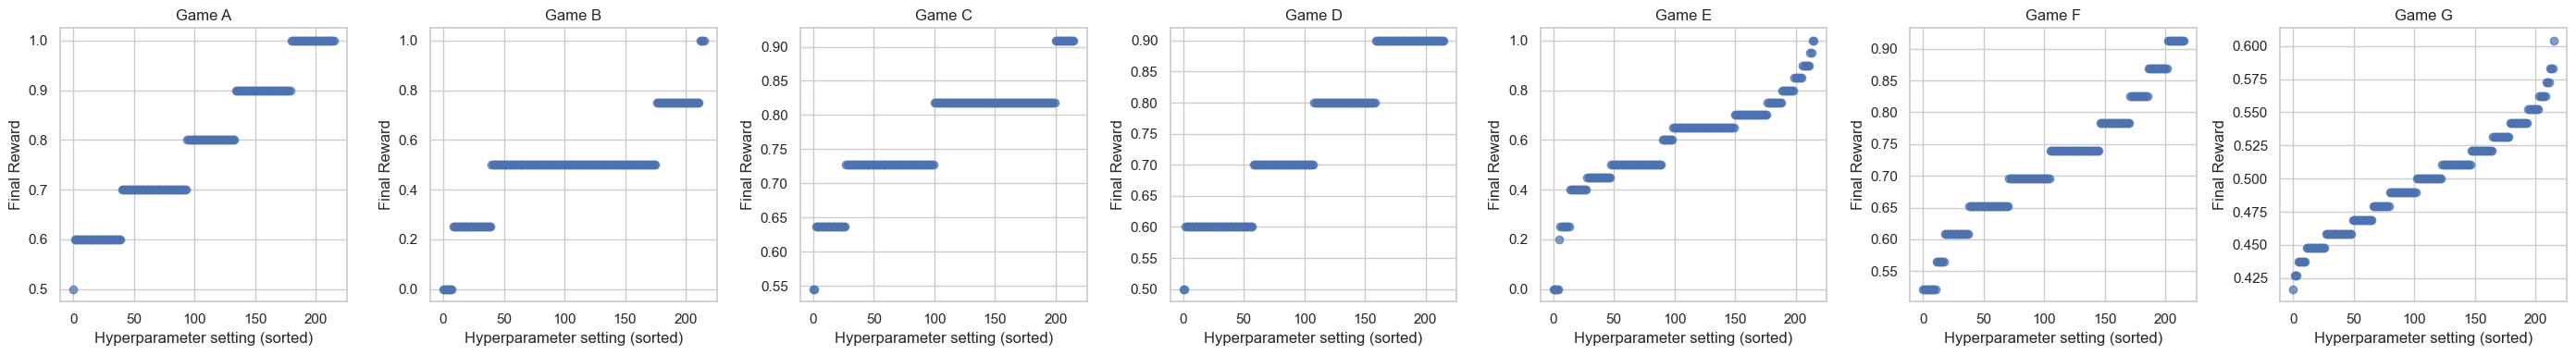

In [7]:
plot_all_loss(results)
plot_all_reward(results)

In [8]:
TOP_X_RL = 5

--- Visualizing Top 5 Configurations for DTDE_QLearning ---

🔹 RANK 1 | ID: Unknown | SOLVED: 0/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 250,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999
}


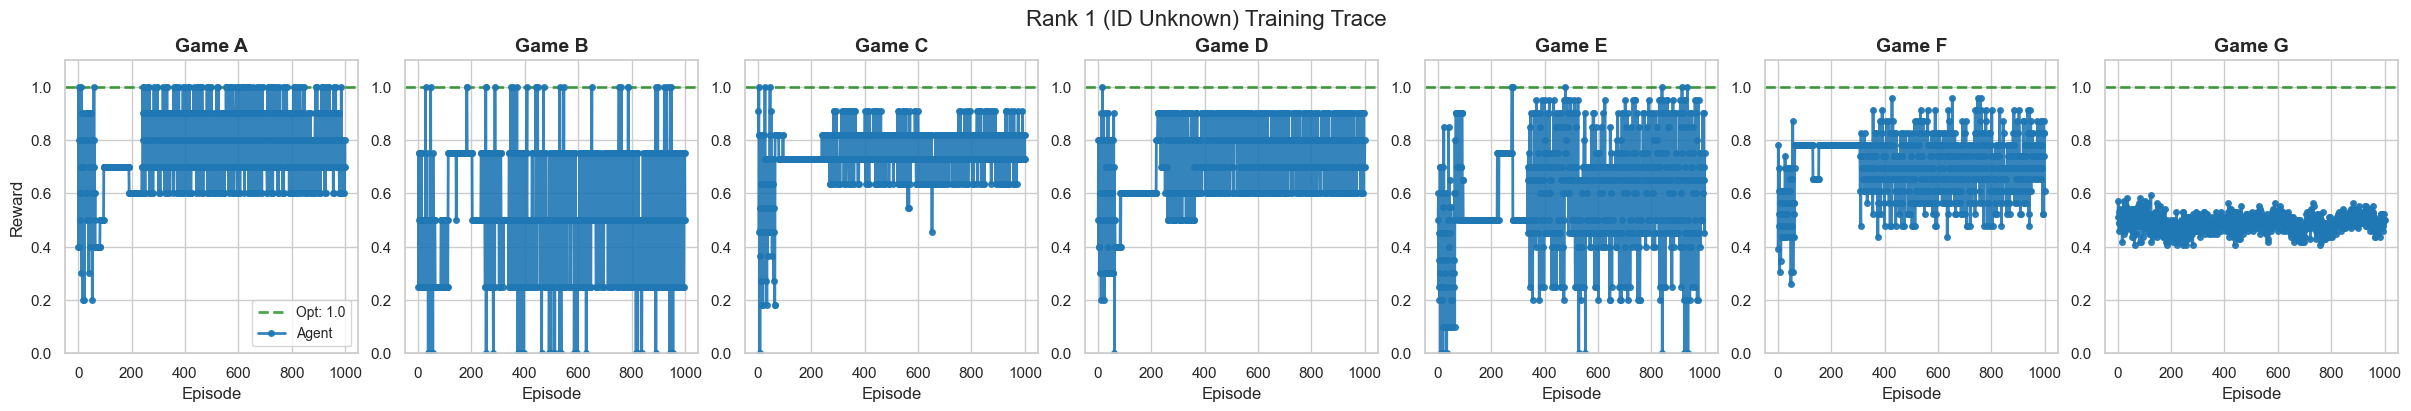


🔹 RANK 2 | ID: Unknown | SOLVED: 10/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 500,
    "epsilon_start": 1.0,
    "epsilon_min": 0.1,
    "epsilon_decay": 0.9995
}


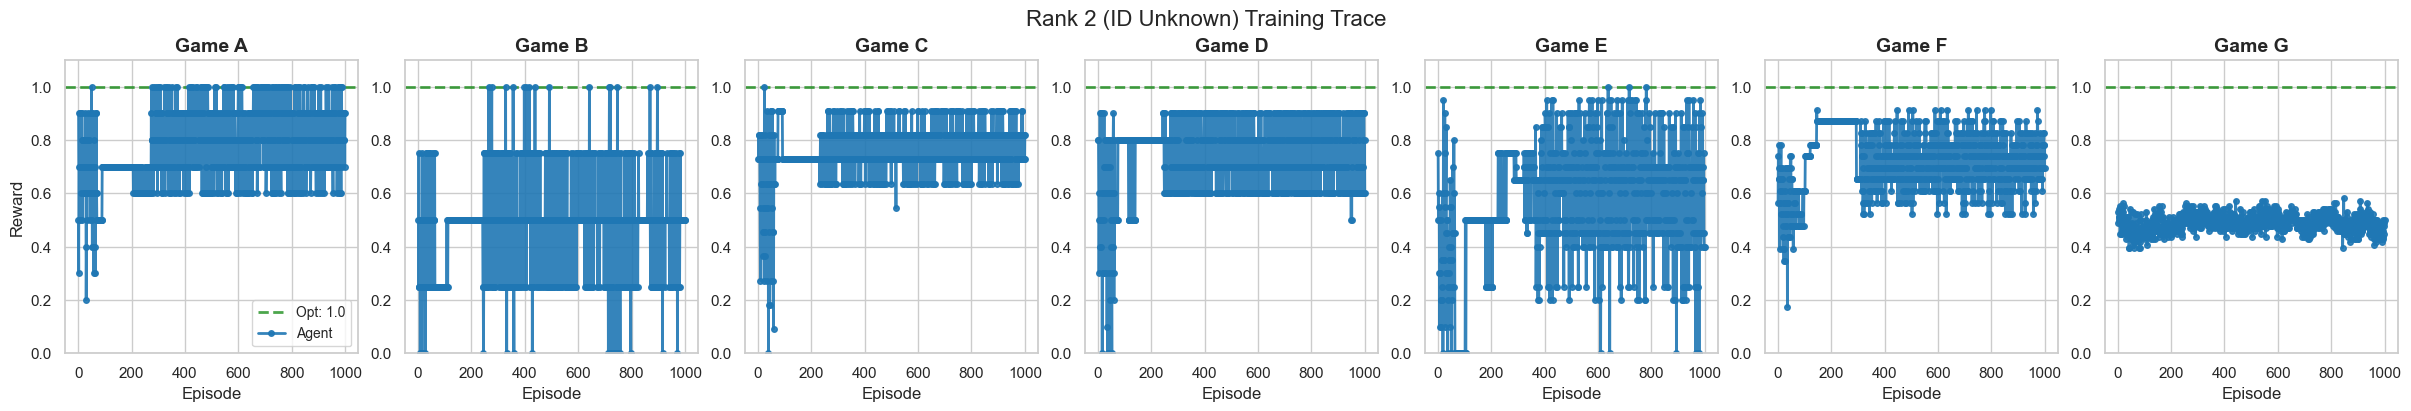


🔹 RANK 3 | ID: Unknown | SOLVED: 11/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 500,
    "epsilon_start": 1.0,
    "epsilon_min": 0.1,
    "epsilon_decay": 0.9999
}


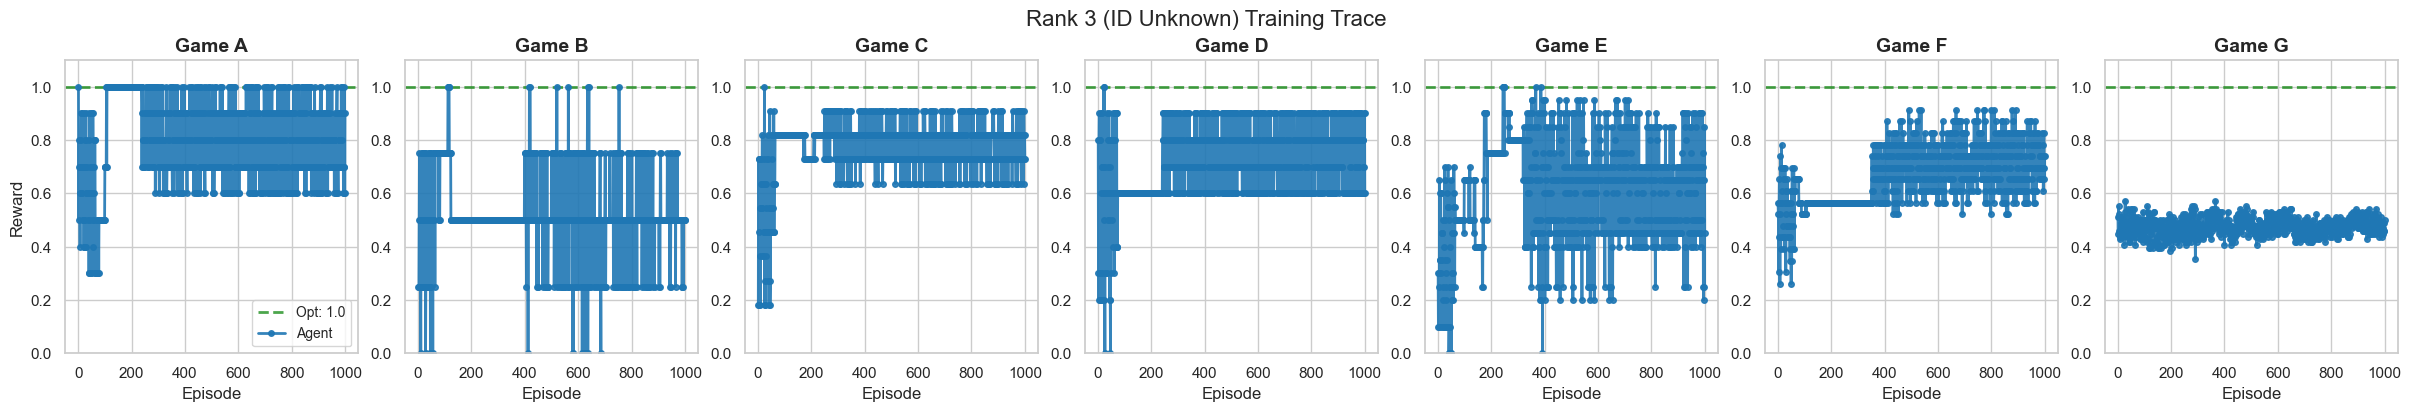


🔹 RANK 4 | ID: Unknown | SOLVED: 12/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 1000,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999
}


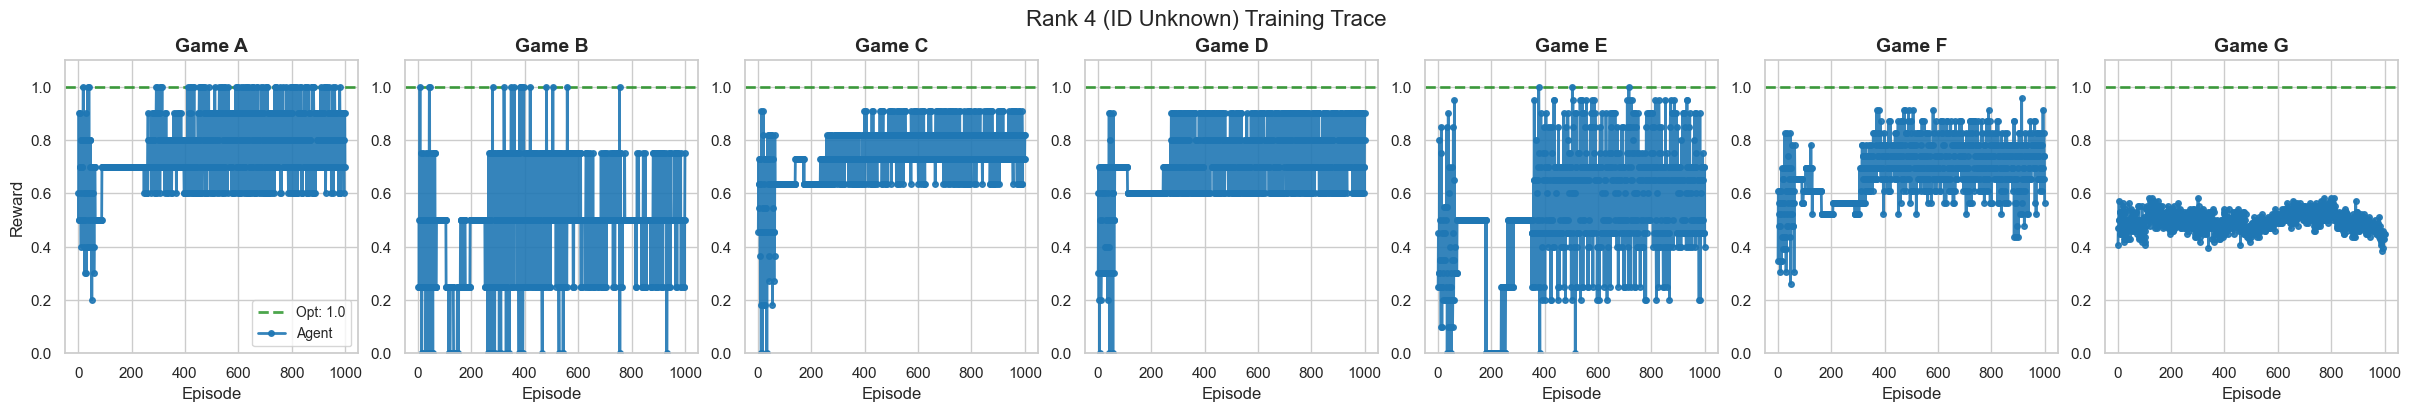


🔹 RANK 5 | ID: Unknown | SOLVED: 13/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 1000,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.9995
}


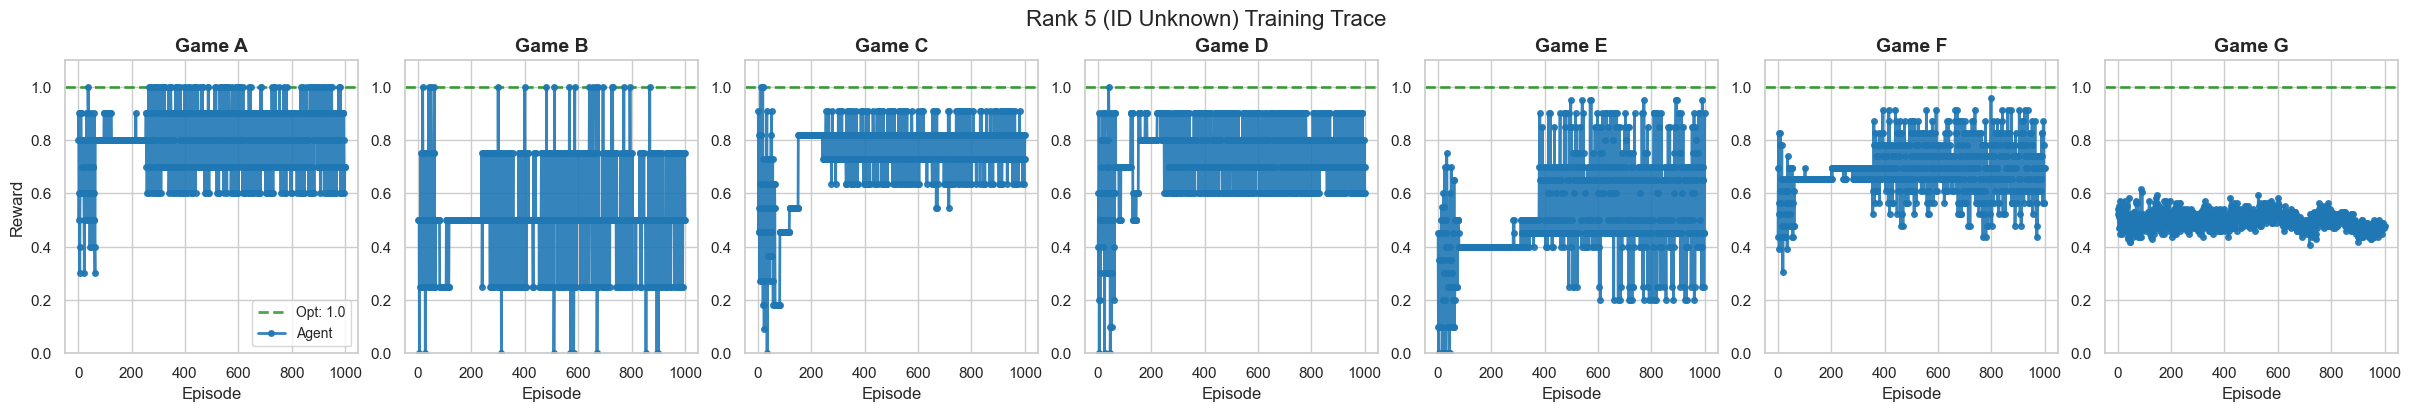

In [11]:
visualize_agent_performance(results_list=results, agent_name=AGENT_NAME, top_n=TOP_X_RL)

In [9]:
selected_params = {
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 64,
    "buffer_size": 250,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999
}
save_best_params(AGENT_NAME, selected_params)

✅ Params saved to: Results\IQ_Learning\best_params.json


### VDN - Model Free

In [10]:
AGENT_NAME = "VDN"
results = load_hyperparameter_results(AGENT_NAME)

Loading 216 files for VDN...


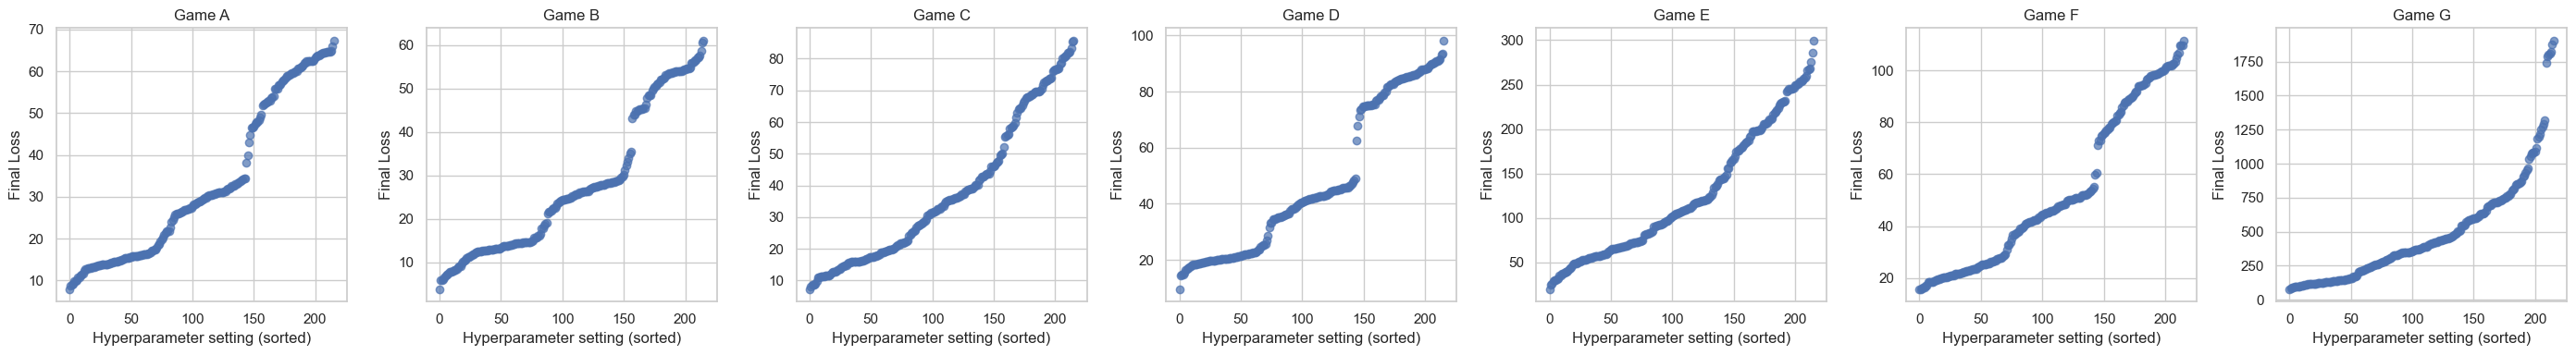

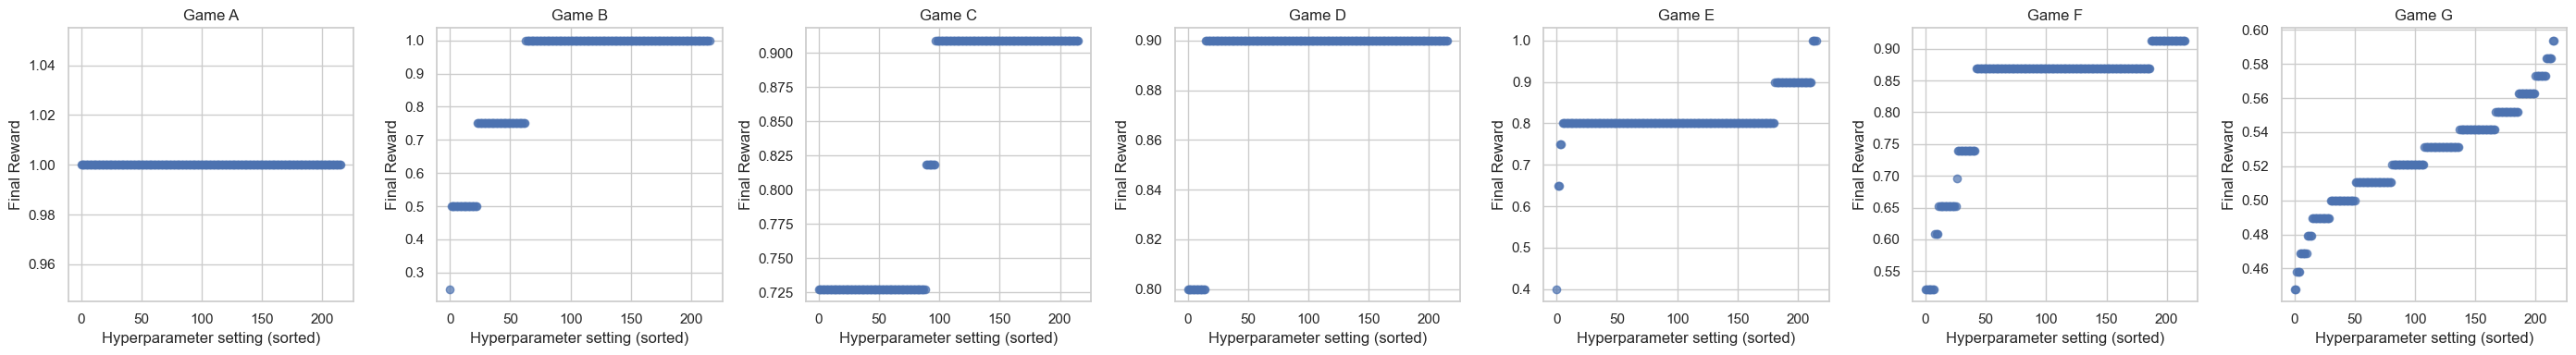

In [11]:
plot_all_loss(results)
plot_all_reward(results)

In [13]:
TOP_X_VI = 4

--- Visualizing Top 4 Configurations for VDN ---

🔹 RANK 1 | ID: Unknown | SOLVED: 0/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 32,
    "updates_per_train": 1,
    "buffer_size": 250,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999
}


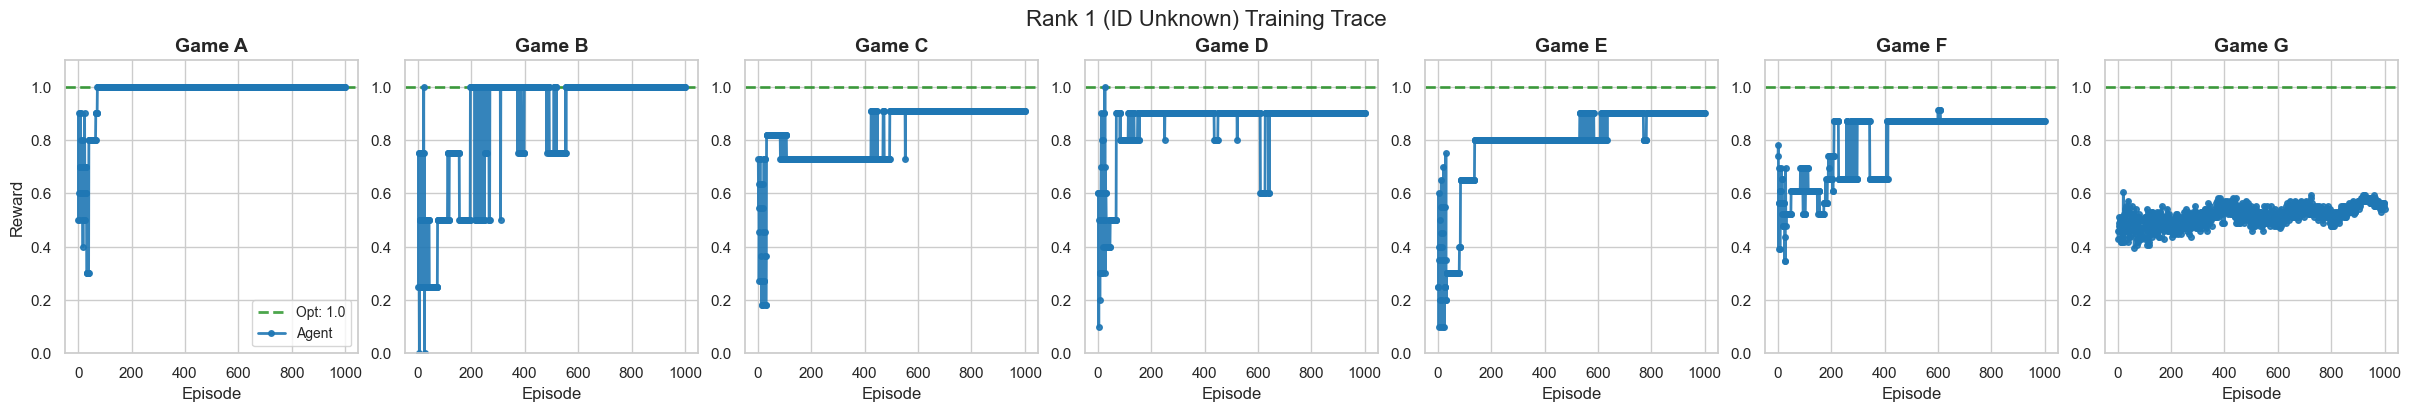


🔹 RANK 2 | ID: Unknown | SOLVED: 100/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 128,
    "updates_per_train": 3,
    "buffer_size": 500,
    "epsilon_start": 1.0,
    "epsilon_min": 0.1,
    "epsilon_decay": 0.9995
}


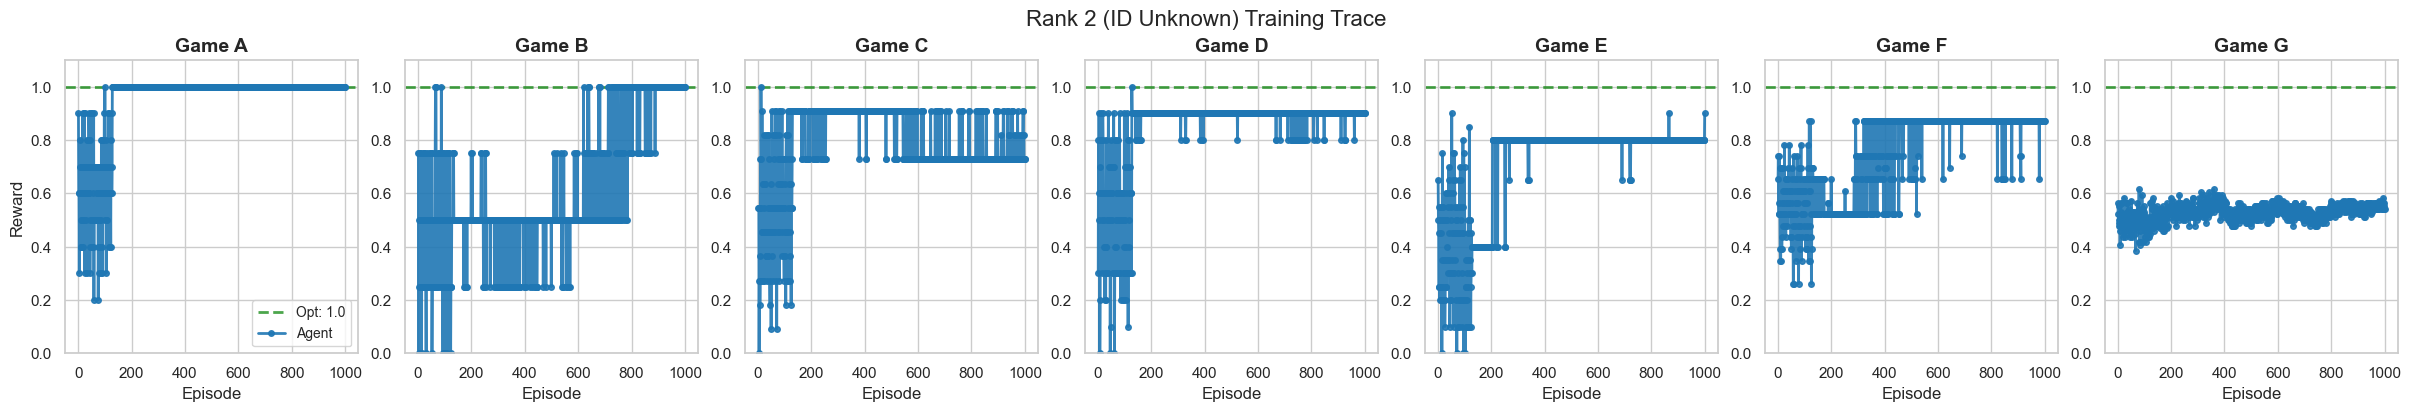


🔹 RANK 3 | ID: Unknown | SOLVED: 101/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 128,
    "updates_per_train": 3,
    "buffer_size": 500,
    "epsilon_start": 1.0,
    "epsilon_min": 0.1,
    "epsilon_decay": 0.9999
}


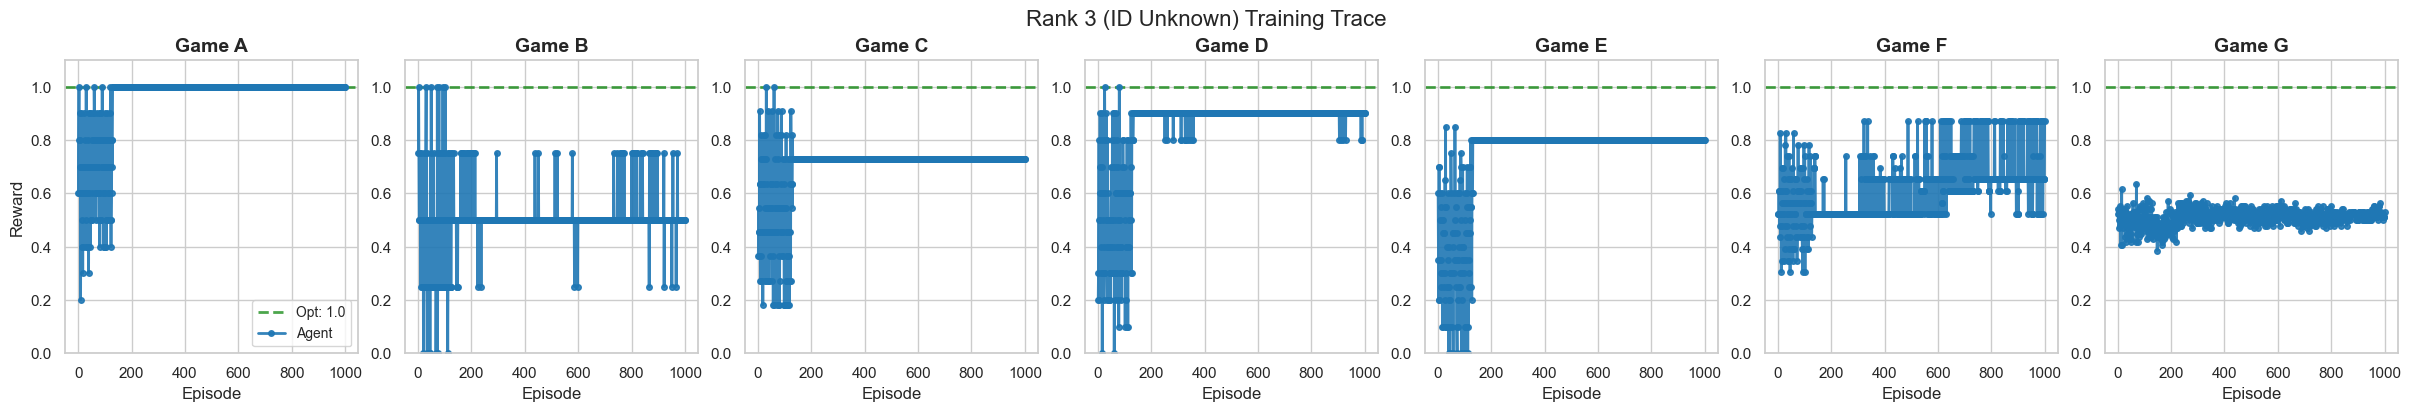


🔹 RANK 4 | ID: Unknown | SOLVED: 102/6
----------------------------------------------------------------------------------------------------
{
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 128,
    "updates_per_train": 3,
    "buffer_size": 1000,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999
}


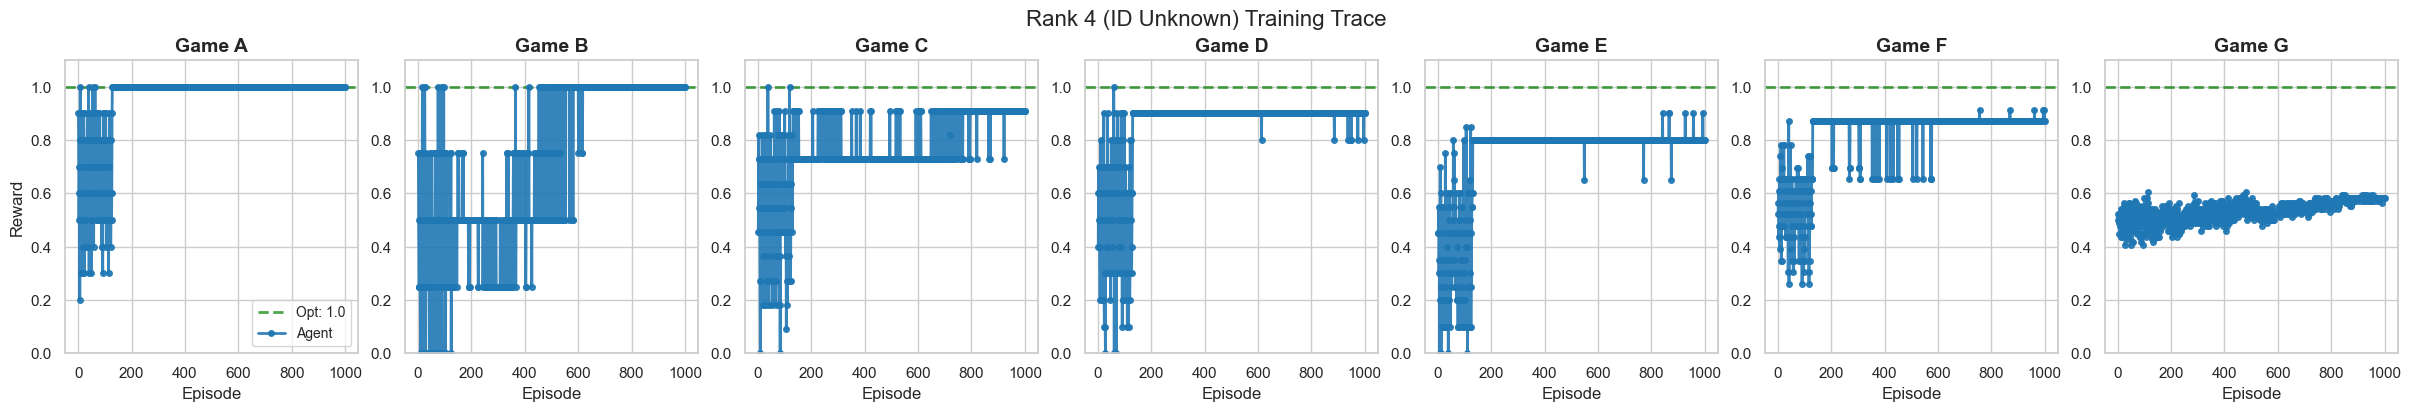

In [14]:
visualize_agent_performance(results, AGENT_NAME, top_n=TOP_X_VI)

In [15]:
selected_params = {
    "lr": 0.01,
    "gamma": 0.99,
    "batch_size": 32,
    "updates_per_train": 1,
    "buffer_size": 250,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999
}
save_best_params(AGENT_NAME, selected_params)

✅ Params saved to: Results\VDN\best_params.json


### Multi-Agent Belief Dynamic Programming - Model Based

In [16]:
AGENT_NAME = "MA_Belief_DP" # Matches your config key
results = load_hyperparameter_results(AGENT_NAME)

Loading 4 files for MA_Belief_DP...


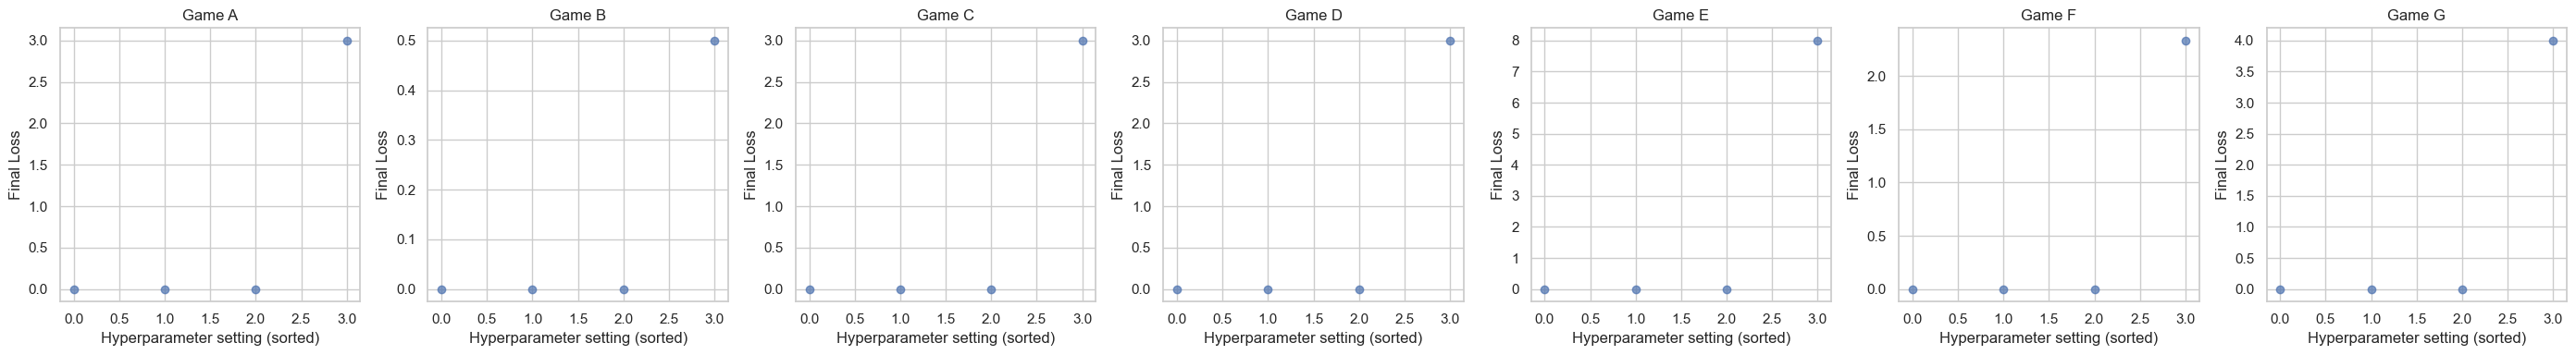

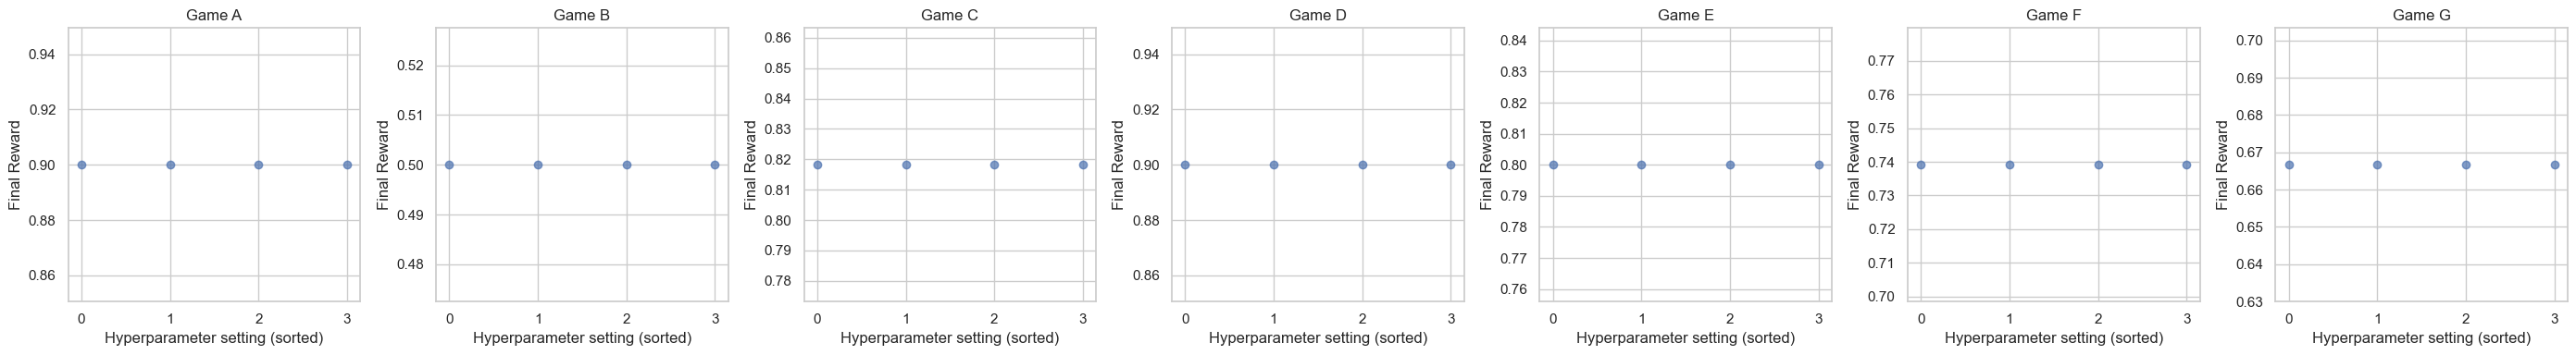

In [17]:
plot_all_loss(results)
plot_all_reward(results)

In [18]:
TOP_X_VDN = 4

--- Visualizing Top 4 Configurations for MA_Belief_DP ---

🔹 RANK 1 | ID: Unknown | SOLVED: 0/6
----------------------------------------------------------------------------------------------------
{
    "max_iterations": 1,
    "attempts": 3
}


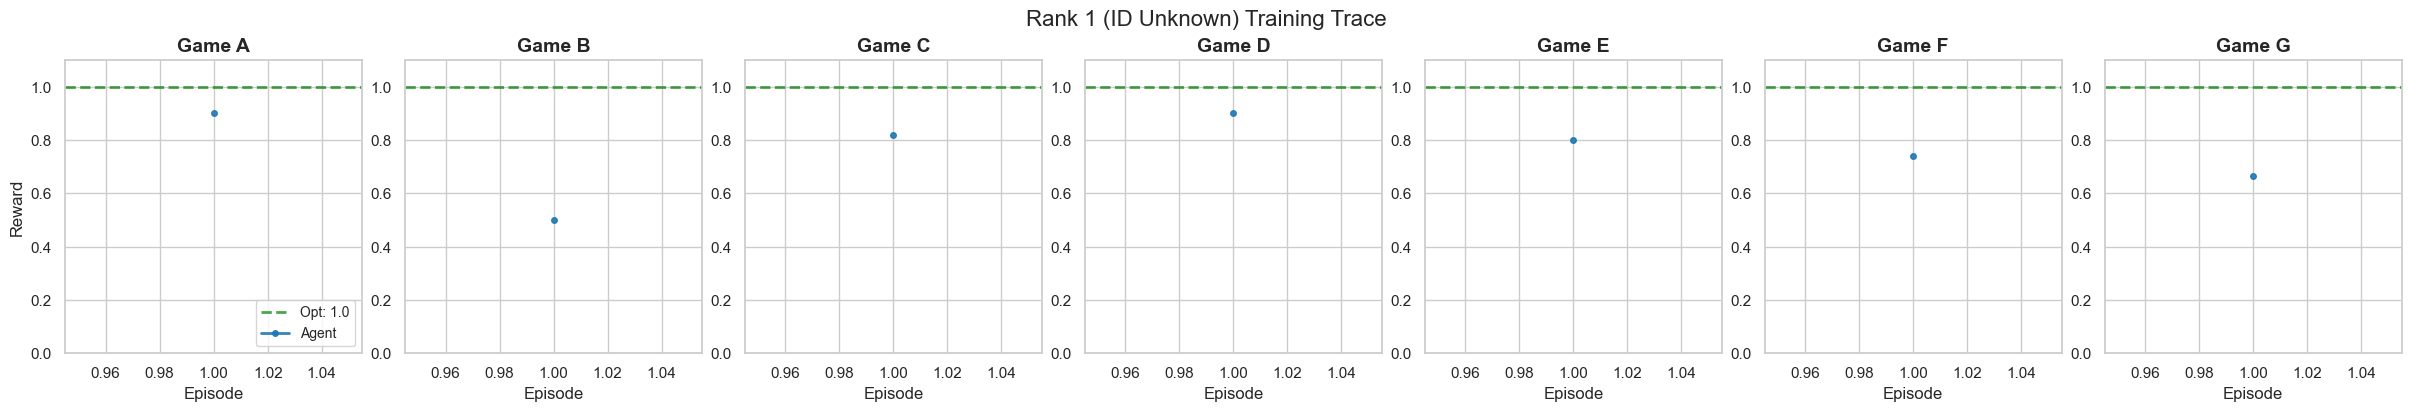


🔹 RANK 2 | ID: Unknown | SOLVED: 1/6
----------------------------------------------------------------------------------------------------
{
    "max_iterations": 5,
    "attempts": 3
}


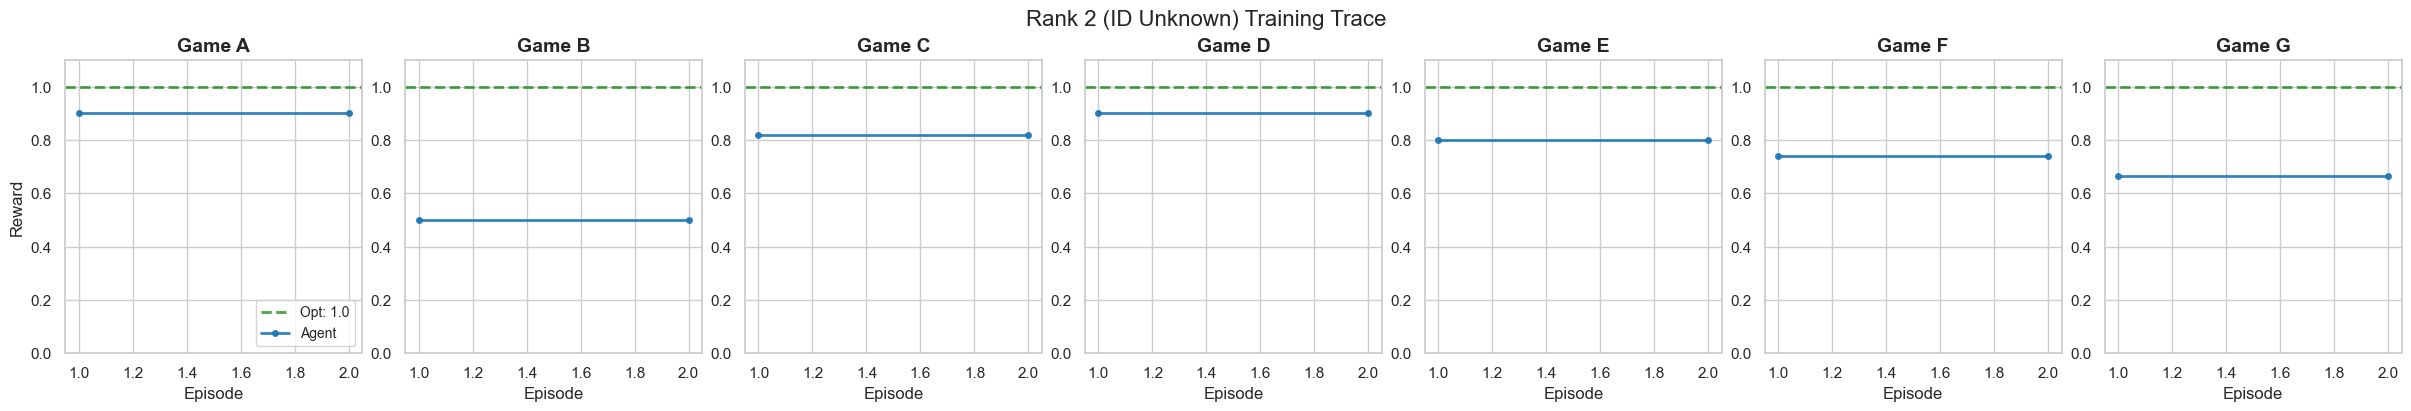


🔹 RANK 3 | ID: Unknown | SOLVED: 2/6
----------------------------------------------------------------------------------------------------
{
    "max_iterations": 10,
    "attempts": 3
}


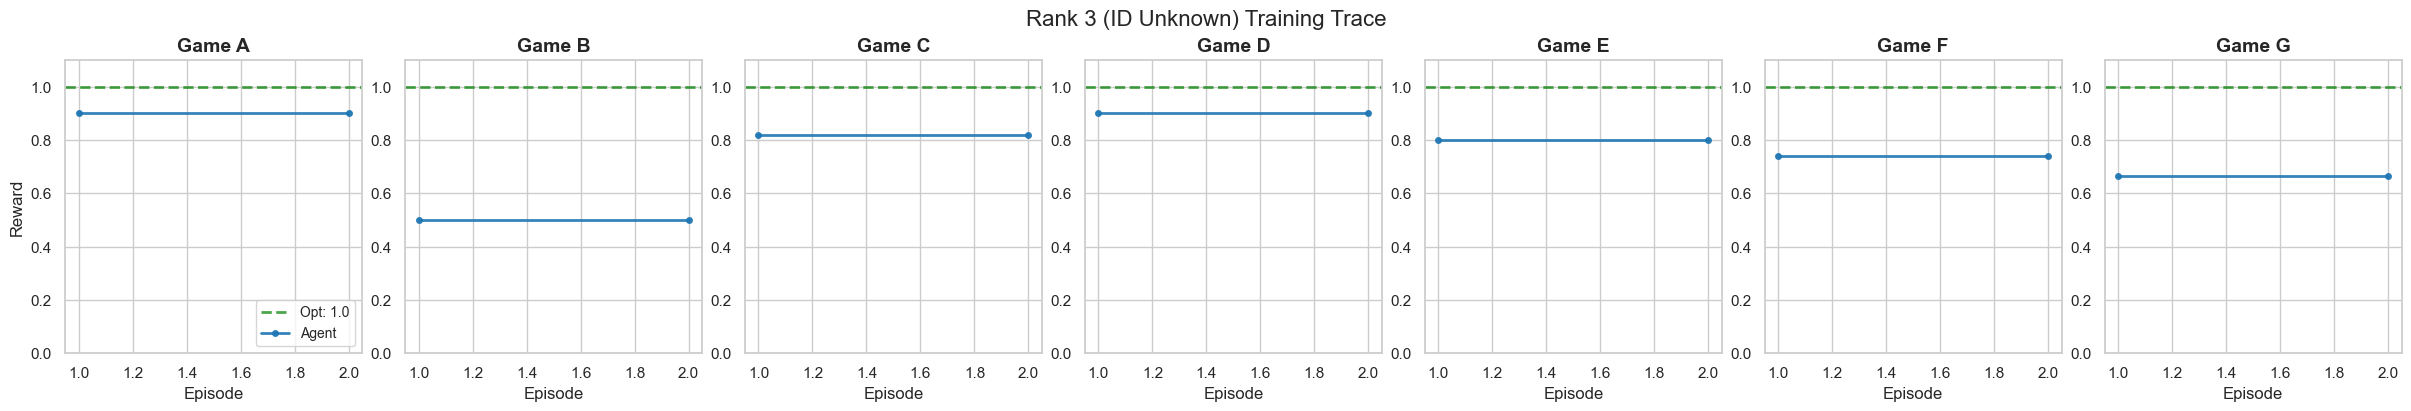


🔹 RANK 4 | ID: Unknown | SOLVED: 3/6
----------------------------------------------------------------------------------------------------
{
    "max_iterations": 50,
    "attempts": 3
}


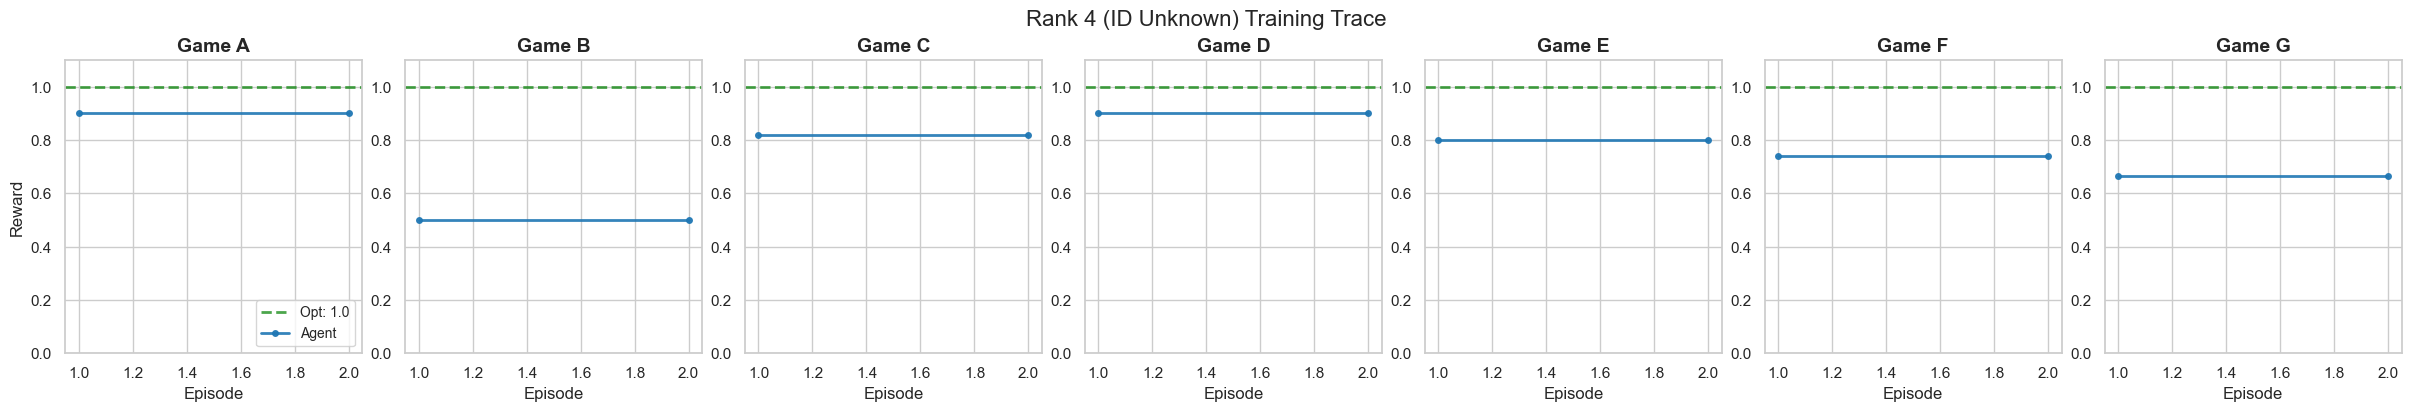

In [19]:
visualize_agent_performance(results, AGENT_NAME, top_n=TOP_X_VDN)

In [20]:
selected_params = {
    "max_iterations": 5,
    "attempts": 3
}
save_best_params(AGENT_NAME, selected_params)

✅ Params saved to: Results\MA_Belief_DP\best_params.json


### PBVI - Model Based

In [21]:
AGENT_NAME = "PBVI" # Matches your config key
results = load_hyperparameter_results(AGENT_NAME)

Loading 4 files for PBVI...


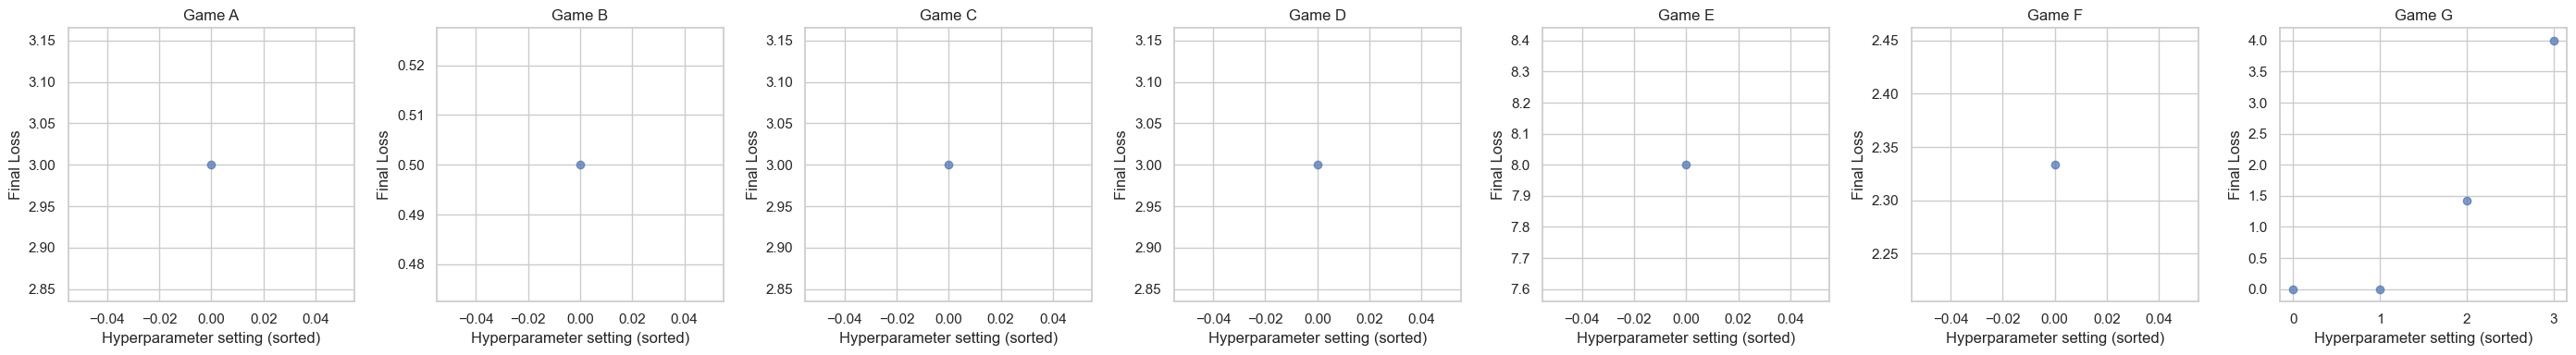

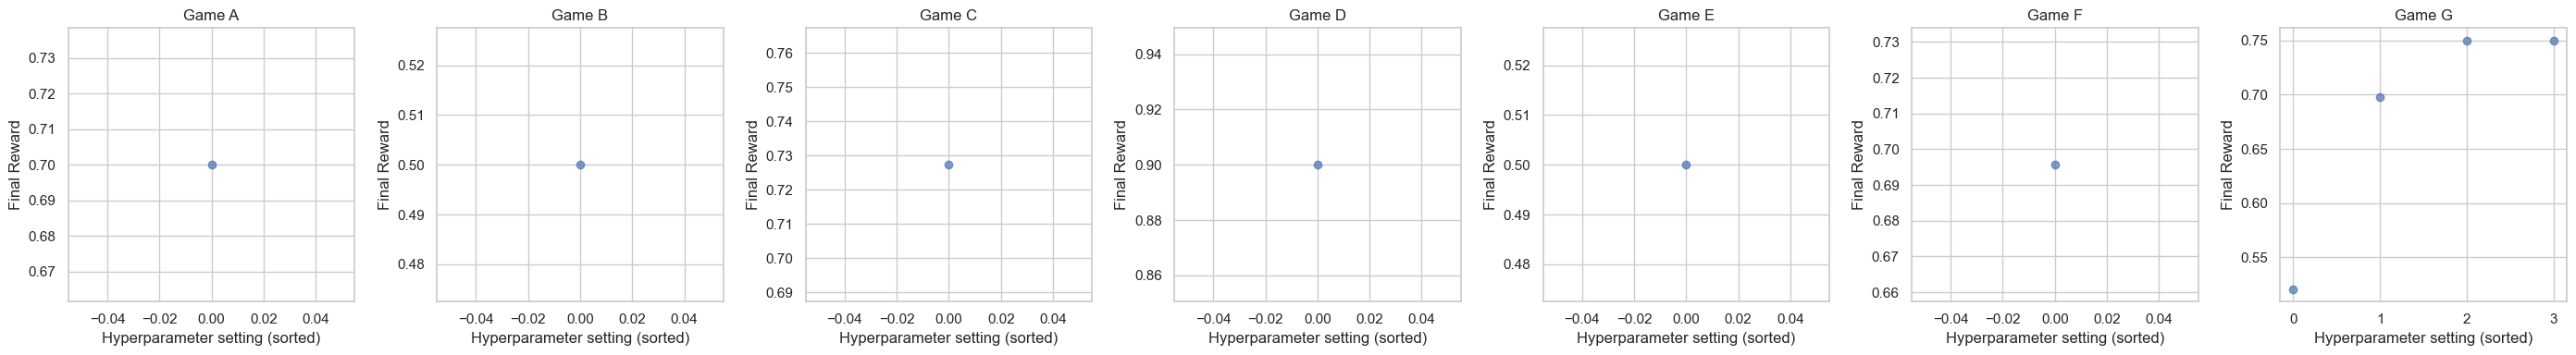

In [22]:
plot_all_loss(results)
plot_all_reward(results)

In [23]:
TOP_X_CTDE = 4

--- Visualizing Top 2 Configurations for CTDE_BI ---

🔹 RANK 1 | ID: Unknown | SOLVED: 0/6
----------------------------------------------------------------------------------------------------
{
    "max_iterations": 1,
    "attempts": 3
}


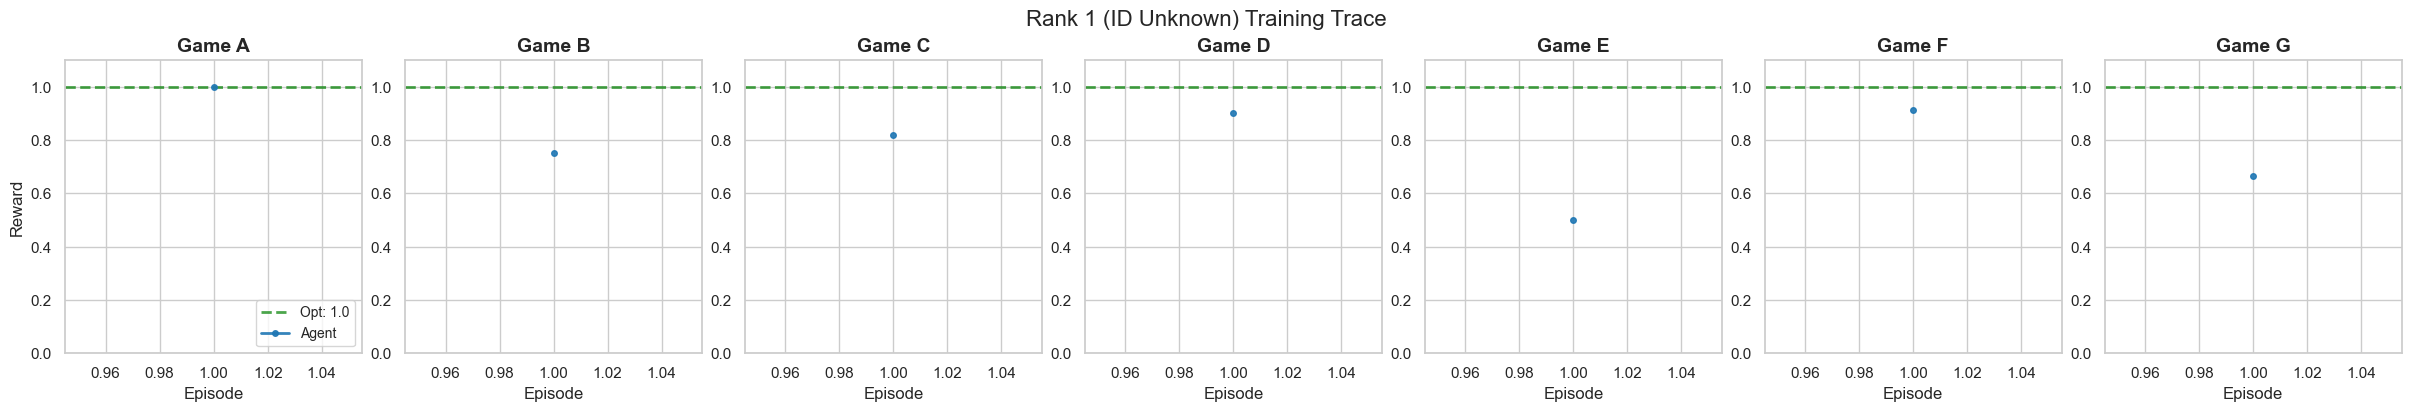


🔹 RANK 2 | ID: Unknown | SOLVED: 1/6
----------------------------------------------------------------------------------------------------
{
    "max_iterations": 5,
    "attempts": 3
}


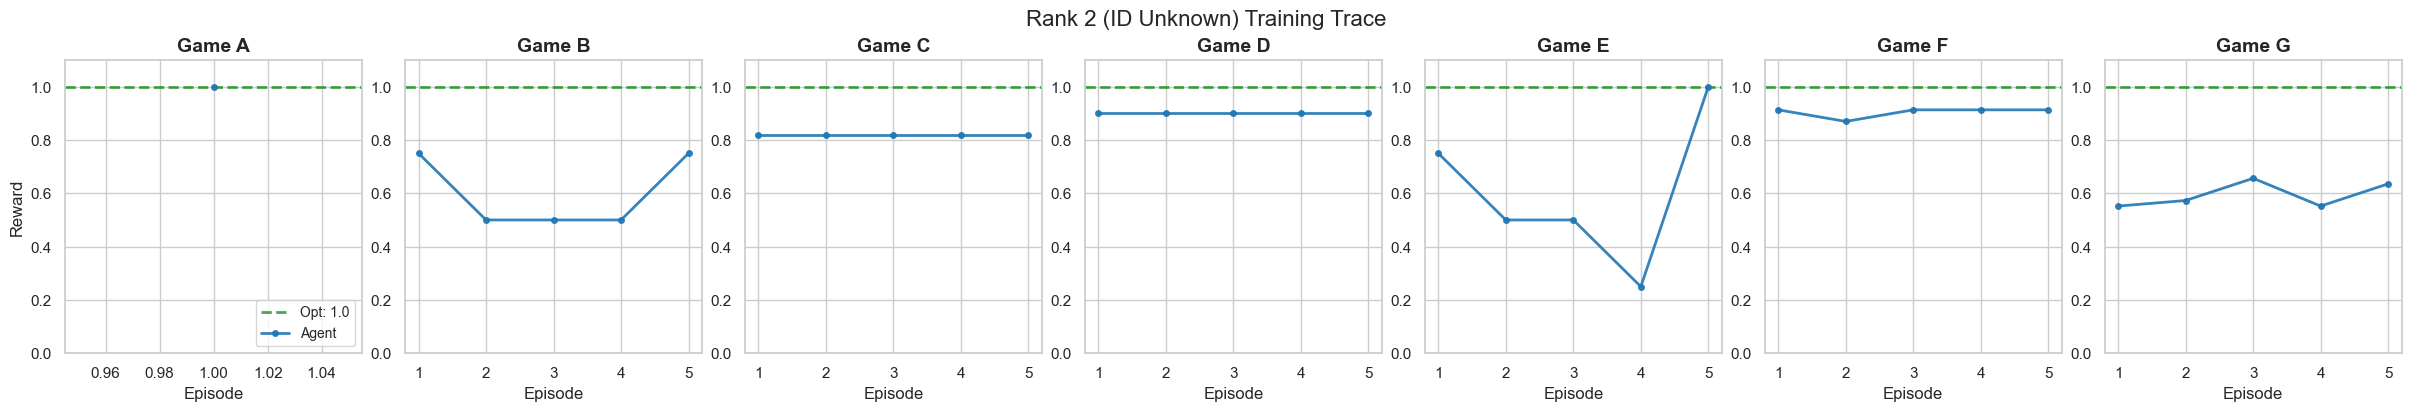

In [26]:
visualize_agent_performance(results, AGENT_NAME, top_n=TOP_X_CTDE)

In [24]:
selected_params = {
    "max_iterations": 5,
    "attempts": 3
}
save_best_params(AGENT_NAME, selected_params)

✅ Params saved to: Results\PBVI\best_params.json
